# P3 – Using Cartopy for Mapping
**Name:** Tristan Mitchell  
**Student Number:** MTCTRI001


## Map 1: Antarctic continent and Southern Ocean from 60°S

**My projection choice:** 
South Polar Stereographic ('ccrs.SouthPolarStereo()')

**Reason for my choice:**  
I chose this projection because it is best suited to Antarctica and the Southern Ocean region. It was designed specifically for the polar regions, placing Antarctica at the centre of the map, and it provides a more accurate view of the area south of 60°S than a standard latitude-longitude projection.

In [2]:
# Import all needed packages:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

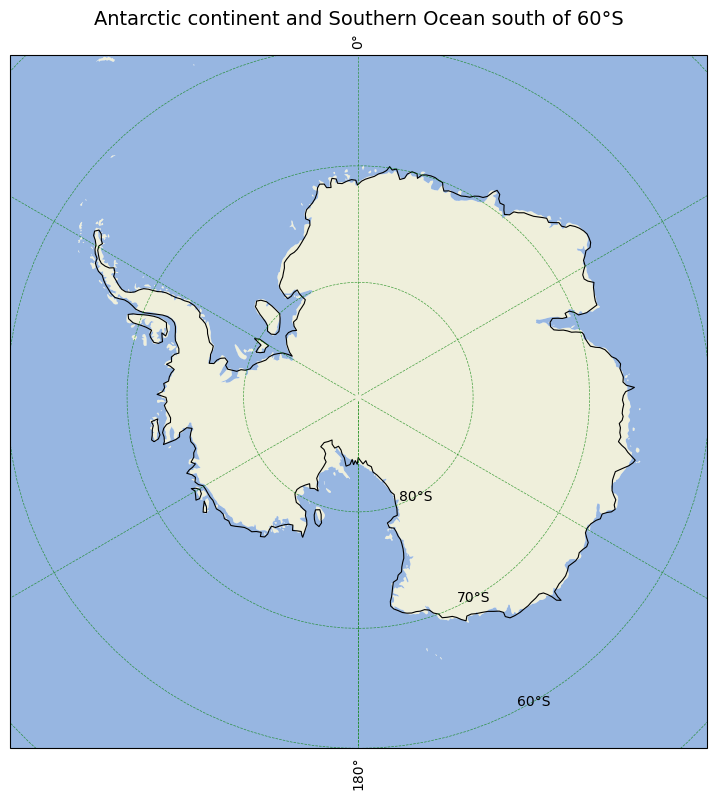

In [12]:
# The Antarctic continent and the Southern Ocean, starting from 60°S

ccrs.SouthPolarStereo(central_longitude=0.0, true_scale_latitude=None, globe=None) # initial projection 
ccrs.PlateCarree(central_longitude=0.0, globe=None) # coordinate system 

# Creating the figure 
fig = plt.figure(figsize=(9, 9))
ax = plt.axes(projection=ccrs.SouthPolarStereo()) # Creating the map axes using the South Polar Stereographic projection type

# Setting the extent of the map with all longitudes, and latitudes from 90-60°S
ax.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())

# Adding other features to enhance the map's appearance:
ax.add_feature(cfeature.LAND) # Adding land areas to the map
ax.add_feature(cfeature.OCEAN) # Adding ocean areas to the map 
ax.coastlines(resolution='110m', linewidth=0.8) # Drawing coastlines from the Natural Earth dataset, using a 1:110 million resolution scale


# Add gridlines showing latitude and longitude
gl = ax.gridlines(
    draw_labels=True, # display the coordinate labels on the map
    linewidth=0.5, # making the gridlines thinner 
    color='g', # grey colouring for the gridlines 
    alpha=0.7, # making the gridlines slightly transparent 
    linestyle='--') # dashed-line style  

# Add labels for the top and right sides to make reading the map easier
gl.top_labels = True
gl.right_labels = True

# Adding a title
ax.set_title("Antarctic continent and Southern Ocean south of 60°S", fontsize=14)

# Showing the plot
plt.show()

## Map 2: South Atlantic, from 20°S to 50°S

**My projection chosen:** 
PlateCarree ('ccrs.PlateCarree()')

**Reason for my choice:**  
The map uses the PlateCarree projection because it produces a rectangular map with straight latitude and longitude lines, making it easy to view multiple locations at once without distorting the map's shape. When displaying locations across large areas, such as the South Atlantic, this map projection provides the clearest and neatest view of different cities. 

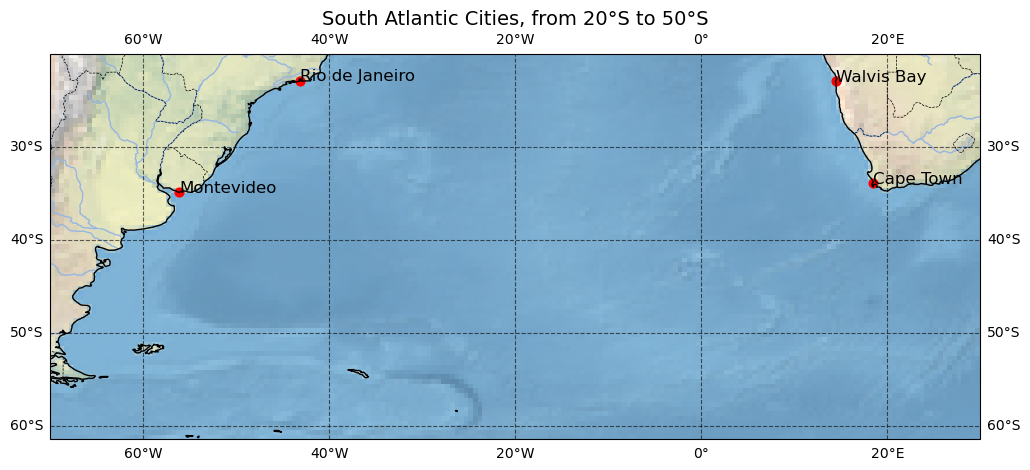

In [10]:
# Map of the South Atlantic, from 20°S to 50°S

# Defining the map's extent: [west, east, south, north]
extent = [-70, 30, -50, -20]

# Defining the locations on the map:
place = ['Walvis Bay', 'Cape Town', 'Rio de Janeiro', 'Montevideo']

# The longitude and latitude coordinates for  each location from Google: 
# Walvis Bay (-22.9575° S, 14.50528° E), Cape Town (-33.9248° S, 18.4299° E), Rio de Janeiro (-22.9068° S, -43.1729° W), Montevideo (-34.90328° S, -56.1856° W)
longitude = [14.505, 18.429, -43.173, -56.185]
latitude = [-22.957, -33.925, -22.907, -34.903]

# Creating the map figure 
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree()) # Create the map axes using the PlateCarree projection
ax.set_extent(extent) # Setting the geographic extent of the map

# Adding features to enhance the map's appearance
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.LAND, edgecolor='b') #black edge colour 
ax.add_feature(cfeature.RIVERS)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle='--') # adding country boarders to the map 
ax.stock_img()
ax.coastlines()

# Adding the gridlines 
gl = ax.gridlines(draw_labels=True,    
                  linestyle='--',
                  color='black',
                  alpha=0.6)

# Add labels for the top and right sides to make reading the map easier
gl.top_labels = True
gl.right_labels = True

# Plotting the cities' locations
ax.scatter(longitude, latitude, color='r', s=40, transform=ccrs.PlateCarree())

# Loop through the list of places and add their names at the corresponding coordinates on the map
for p in range(len(place)):
    ax.text(longitude[p], latitude[p], place[p], fontsize=12,  transform=ccrs.Geodetic())

# Adding a title
ax.set_title('South Atlantic Cities, from 20°S to 50°S', fontsize=14)

# Showing the plot
plt.show()

## Map 3: False Bay coastline resolution comparison

**My projection chosen:** 
PlateCarree ('ccrs.PlateCarree()')

**Reason for my choice:**  
For this figure, I chose the PlateCarree projection. It is suitable because False Bay covers a small geographic area, resulting in minimal map projection distortion. I used the same extent in all three panels, making comparison easier and demonstrating how the coastline becomes more detailed from coarse to intermediate to full resolution. 

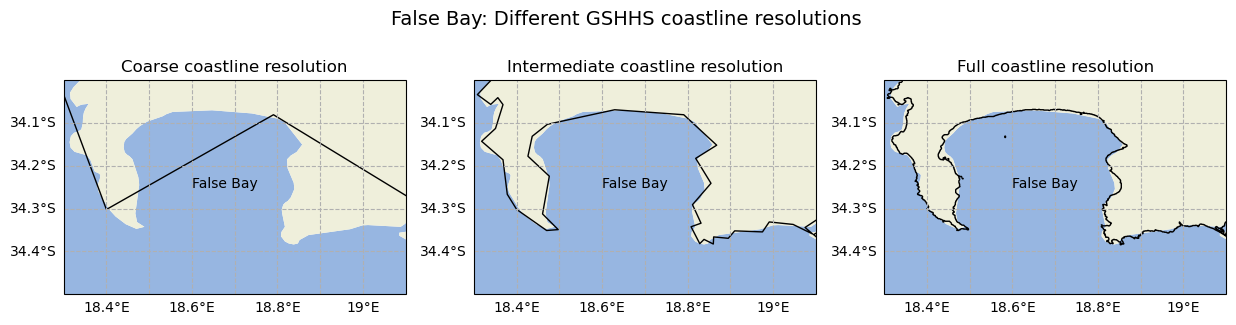

In [4]:
# Different coastline resolutions from the GSHHG database in a map of False Bay

# Creating coastline features from the GSHHS database
cl_coarse = cfeature.GSHHSFeature(scale='c') # coarse resolution coastline
cl_intermediate = cfeature.GSHHSFeature(scale='i')  # intermediate resolution coastline
cl_full = cfeature.GSHHSFeature(scale='f') # full resolution coastline


# Defining the map extent for False Bay [west, east, north, south]
extent = [18.3, 19.1, -34.0, -34.5]

# Creating a figure with three side-by-side map panels
fig, ax = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': ccrs.PlateCarree()})

# Coarse coastline resolution panal 
ax[0].set_extent(extent)
ax[0].add_feature(cfeature.OCEAN)
ax[0].add_feature(cfeature.LAND)
ax[0].add_feature(cl_coarse)  # draw the coastline using coarse GSHHS resolution
ax[0].set_title('Coarse coastline resolution') # creating a title for the first panal 

gl0 = ax[0].gridlines(draw_labels=True, linestyle='--') # Add latitude and longitude gridlines with coordinate labels
gl0.top_labels = False # removing longitude labels from the top of the map
gl0.right_labels = False # removing latitude labels from the right side of the map 

ax[0].text(18.6, -34.25, 'False Bay', fontsize=10, transform=ccrs.PlateCarree())

# Intermediate coastline resolution panal
ax[1].set_extent(extent)
ax[1].add_feature(cfeature.OCEAN)
ax[1].add_feature(cfeature.LAND)
ax[1].add_feature(cl_intermediate) # draw coastline using intermediate resolution
ax[1].set_title('Intermediate coastline resolution')
    
gl1 = ax[1].gridlines(draw_labels=True, linestyle='--')
gl1.top_labels = False
gl1.right_labels = False
gl1.left_labels = True

ax[1].text(18.6, -34.25, 'False Bay', fontsize=10, transform=ccrs.PlateCarree())

# Full coastline resolution panal
ax[2].set_extent(extent)
ax[2].add_feature(cfeature.OCEAN)
ax[2].add_feature(cfeature.LAND)
ax[2].add_feature(cl_full)  # draw coastline using full GSHHS resolution
ax[2].set_title('Full coastline resolution')

gl2 = ax[2].gridlines(draw_labels=True, linestyle='--')
gl2.top_labels = False
gl2.right_labels = False
gl2.left_labels = True

# Adding a label to identify where False Bay is located on the map 
ax[2].text(18.6, -34.25, 'False Bay', fontsize=10, transform=ccrs.PlateCarree())

# Adding a title
plt.suptitle('False Bay: Different GSHHS coastline resolutions', fontsize=14, y=0.85) # the y value controls the vertical position on the title 

# Showing the plot
plt.show()
